In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
import os

import pandas as pd


os.chdir(Path.cwd().parent)
print("new cwd:", Path.cwd())

new cwd: /home/oliver-hertach/Documents/Master/CO4/ClimbingVault


## Shared constants

In [2]:
colors = {
    "red": [255, 0, 0],
    "blue": [0, 0, 255],
    "green": [0, 255, 0],
    "yellow": [255, 255, 0],
    "orange": [255, 165, 0],
    "purple": [128, 0, 128],
    "pink" : [255, 105, 180],
    "black": [0, 0, 0],
    "downclimb": [128, 128, 128],
}

## Shared functions

In [3]:
def load_sample(img_id):
    img = cv.imread(f"data/images/{img_id}.jpg")

    mask_dir = f"data/masks/{img_id}"
    
    masks = {}
    
    for file in os.listdir(mask_dir):
        if file.endswith(".png"):
            color = file.replace(".png", "")
            masks[color] = cv.imread(os.path.join(mask_dir, file), 0)

    return img, masks

# Dice score
def dice_score(gt, pred):
    intersection = np.sum(gt * pred)
    return (2 * intersection) / (np.sum(gt) + np.sum(pred))

## Combined plotting of RGB vs HSV vs YUV

RGB Dice: 0.08542657198437073
HSV Dice: 0.6550769464447221
YUV Dice: 0.4159076916544594


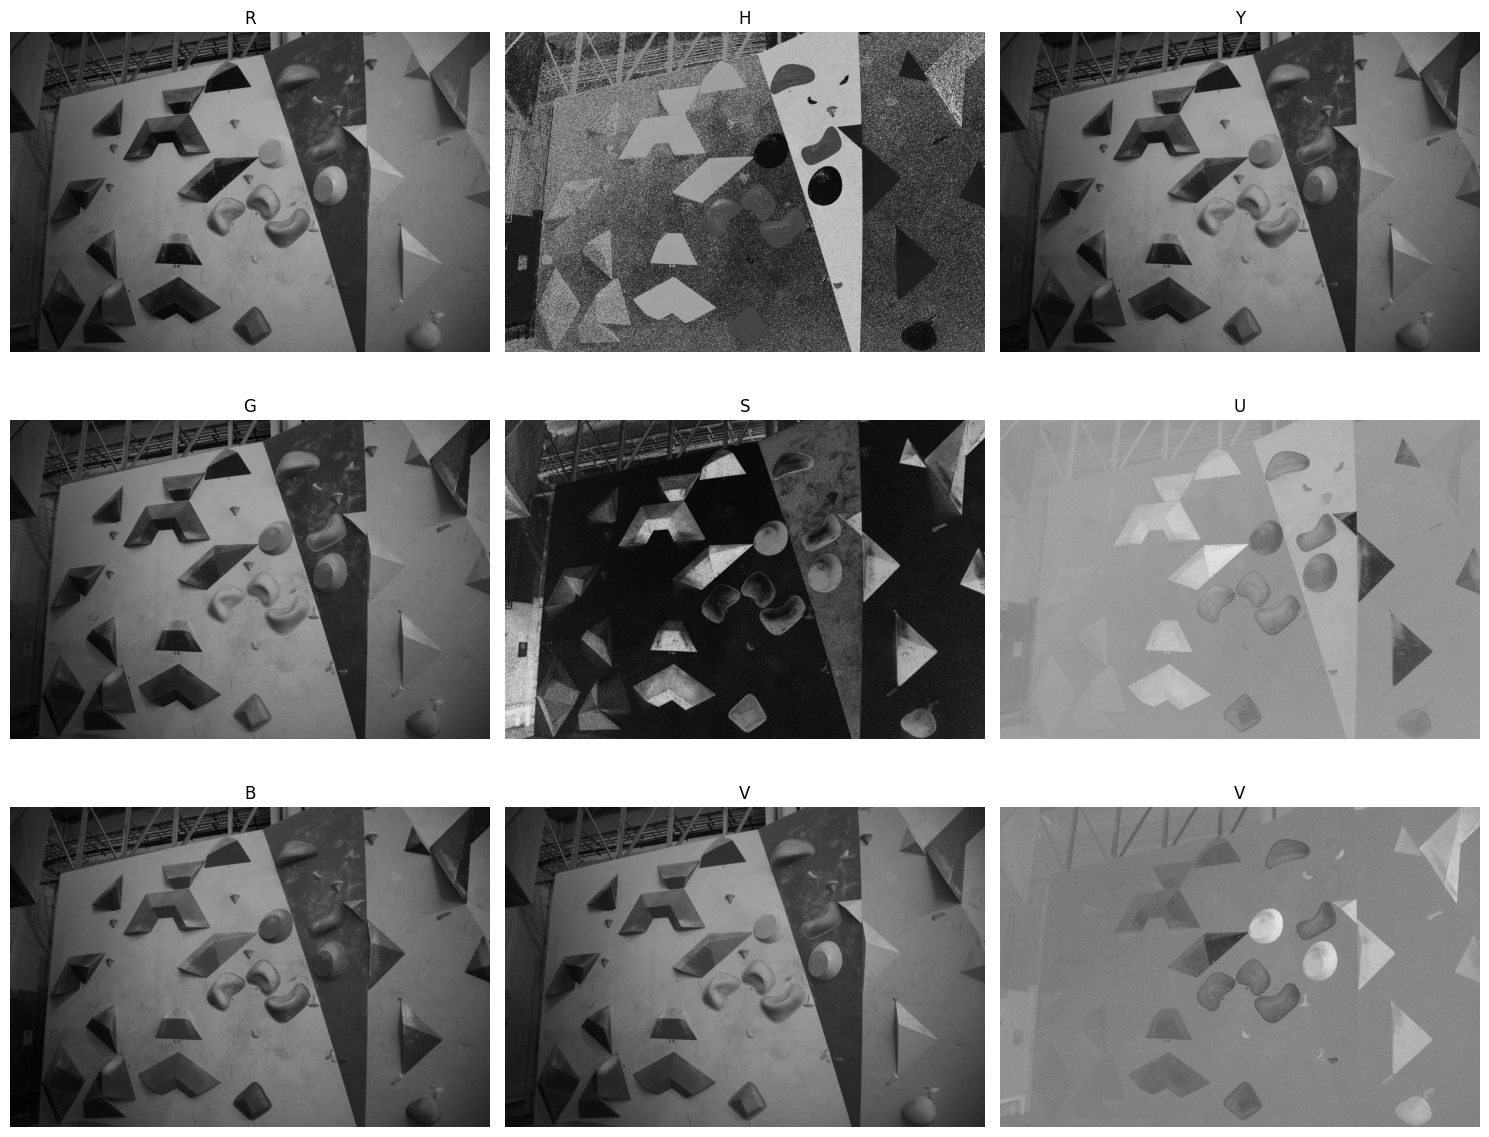

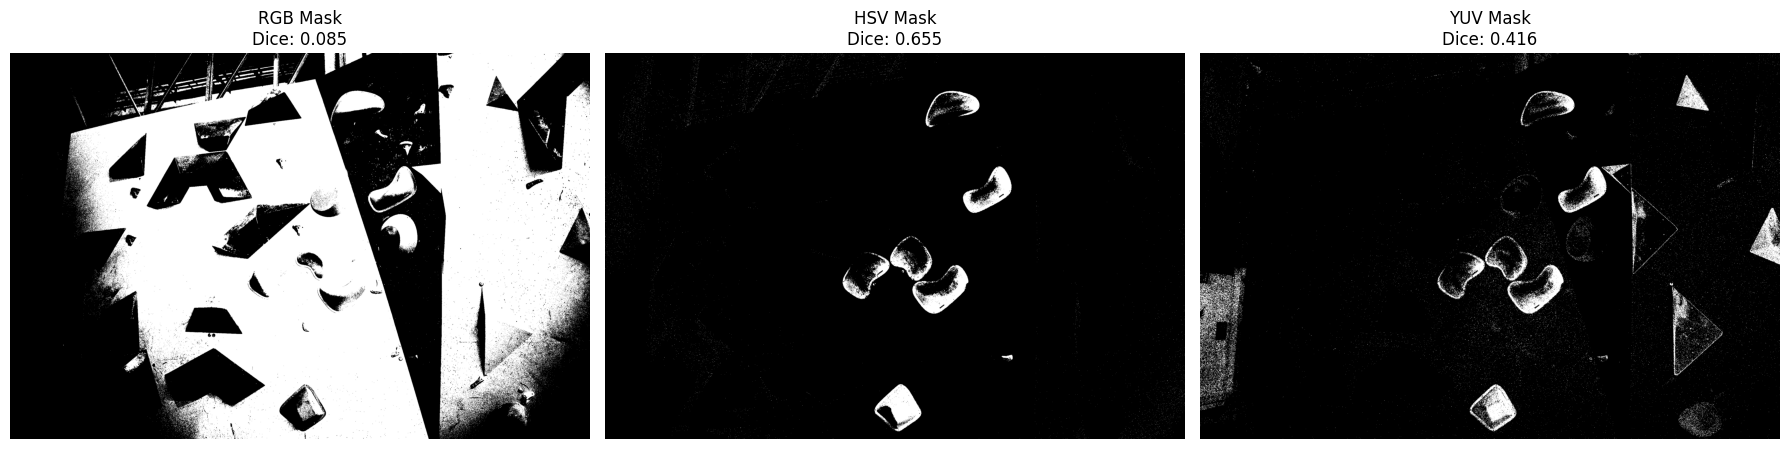

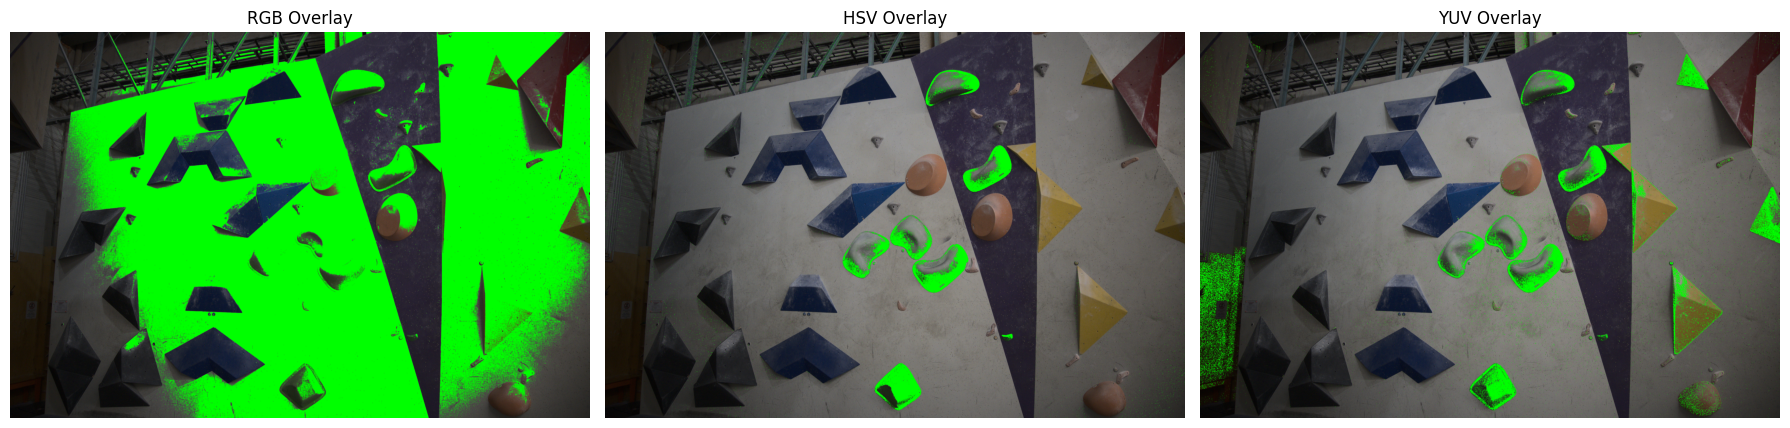

In [4]:
img_id = "008"

img, masks = load_sample(img_id)

# Convert color spaces
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
yuv = cv.cvtColor(img, cv.COLOR_BGR2YUV)

# Ground truth
gt = (masks["green"] > 0).astype(np.uint8)

# -----------------------------
# RGB segmentation
# -----------------------------
rgb_lower = np.array([0, 80, 0])
rgb_upper = np.array([180, 255, 180])

rgb_mask = cv.inRange(img_rgb, rgb_lower, rgb_upper)
rgb_pred = (rgb_mask > 0).astype(np.uint8)

# -----------------------------
# HSV segmentation
# -----------------------------
hsv_lower = np.array([35, 50, 50])
hsv_upper = np.array([85, 255, 255])

hsv_mask = cv.inRange(hsv, hsv_lower, hsv_upper)
hsv_pred = (hsv_mask > 0).astype(np.uint8)

# -----------------------------
# YUV segmentation
# -----------------------------
yuv_lower = np.array([0, 40, 0])
yuv_upper = np.array([255, 120, 140])

yuv_mask = cv.inRange(yuv, yuv_lower, yuv_upper)
yuv_pred = (yuv_mask > 0).astype(np.uint8)

# -----------------------------
# Dice scores
# -----------------------------
rgb_dice = dice_score(gt, rgb_pred)
hsv_dice = dice_score(gt, hsv_pred)
yuv_dice = dice_score(gt, yuv_pred)

print("RGB Dice:", rgb_dice)
print("HSV Dice:", hsv_dice)
print("YUV Dice:", yuv_dice)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# -------------------
# RGB
# -------------------

# title
axes[0,0].set_ylabel("RGB", rotation=0, labelpad=40)
axes[0,1].set_ylabel("HSV", rotation=0, labelpad=40)
axes[0,2].set_ylabel("YUV", rotation=0, labelpad=40)

axes[0,0].imshow(img_rgb[:,:,0], cmap="gray")
axes[0,0].set_title("R")
axes[0,0].axis("off")

axes[1,0].imshow(img_rgb[:,:,1], cmap="gray")
axes[1,0].set_title("G")
axes[1,0].axis("off")

axes[2,0].imshow(img_rgb[:,:,2], cmap="gray")
axes[2,0].set_title("B")
axes[2,0].axis("off")

# -------------------
# HSV
# -------------------
axes[0,1].imshow(hsv[:,:,0], cmap="gray")
axes[0,1].set_title("H")
axes[0,1].axis("off")

axes[1,1].imshow(hsv[:,:,1], cmap="gray")
axes[1,1].set_title("S")
axes[1,1].axis("off")

axes[2,1].imshow(hsv[:,:,2], cmap="gray")
axes[2,1].set_title("V")
axes[2,1].axis("off")

# -------------------
# YUV
# -------------------
axes[0,2].imshow(yuv[:,:,0], cmap="gray")
axes[0,2].set_title("Y")
axes[0,2].axis("off")

axes[1,2].imshow(yuv[:,:,1], cmap="gray")
axes[1,2].set_title("U")
axes[1,2].axis("off")

axes[2,2].imshow(yuv[:,:,2], cmap="gray")
axes[2,2].set_title("V")
axes[2,2].axis("off")

plt.tight_layout()
plt.show()

# -----------------------------
# MASK VISUALIZATION
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18,6))

axes[0].imshow(rgb_mask, cmap="gray")
axes[0].set_title(f"RGB Mask\nDice: {rgb_dice:.3f}")
axes[0].axis("off")

axes[1].imshow(hsv_mask, cmap="gray")
axes[1].set_title(f"HSV Mask\nDice: {hsv_dice:.3f}")
axes[1].axis("off")

axes[2].imshow(yuv_mask, cmap="gray")
axes[2].set_title(f"YUV Mask\nDice: {yuv_dice:.3f}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# -----------------------------
# OVERLAY VISUALIZATION
# -----------------------------
rgb_overlay = img_rgb.copy()
rgb_overlay[rgb_pred == 1] = [0,255,0]

hsv_overlay = img_rgb.copy()
hsv_overlay[hsv_pred == 1] = [0,255,0]

yuv_overlay = img_rgb.copy()
yuv_overlay[yuv_pred == 1] = [0,255,0]

fig, axes = plt.subplots(1, 3, figsize=(18,6))

axes[0].imshow(rgb_overlay)
axes[0].set_title("RGB Overlay")
axes[0].axis("off")

axes[1].imshow(hsv_overlay)
axes[1].set_title("HSV Overlay")
axes[1].axis("off")

axes[2].imshow(yuv_overlay)
axes[2].set_title("YUV Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Baseline loop

### Configuration

In [5]:
img_dir = Path("data/images")

colors_list = list(colors.keys())
image_ids = sorted([f.stem for f in img_dir.glob("*.jpg")])
print(image_ids)


['008', '042', '054', '079', '081', '083', '134', '137', '169', '254']


### Thresholds

In [6]:
thresholds = {
    "HSV": {
        "red":    {"lower": [0, 80, 80], "upper": [10, 255, 255]},
        "green":  {"lower": [35, 50, 50], "upper": [85, 255, 255]},
        "blue":   {"lower": [90, 50, 50], "upper": [130, 255, 255]},
        "yellow": {"lower": [20, 80, 80], "upper": [35, 255, 255]},
        "orange": {"lower": [10, 80, 80], "upper": [20, 255, 255]},
        "purple": {"lower": [130, 50, 50], "upper": [160, 255, 255]},
        "pink":   {"lower": [160, 50, 50], "upper": [180, 255, 255]},
        "black":       {"lower": [0, 0, 0], "upper": [180, 255, 60]},
        "downclimb":   {"lower": [0, 0, 60], "upper": [180, 50, 200]},
    },

    "RGB": {
        "red":    {"lower": [150, 0, 0], "upper": [255, 100, 100]},
        "green":  {"lower": [0, 150, 0], "upper": [100, 255, 100]},
        "blue":   {"lower": [0, 0, 150], "upper": [100, 100, 255]},
        "yellow": {"lower": [150, 150, 0], "upper": [255, 255, 120]},
        "orange": {"lower": [150, 80, 0], "upper": [255, 180, 100]},
        "purple": {"lower": [120, 0, 120], "upper": [200, 100, 255]},
        "pink":   {"lower": [180, 100, 150], "upper": [255, 180, 220]},
        "black":       {"lower": [0, 0, 0], "upper": [60, 60, 60]},
        "downclimb":   {"lower": [120, 120, 120], "upper": [200, 200, 200]},
    },

    "YUV": {
        "red":    {"lower": [0, 0, 150], "upper": [255, 120, 255]},
        "green":  {"lower": [0, 0, 0], "upper": [255, 120, 140]},
        "blue":   {"lower": [0, 140, 0], "upper": [255, 255, 255]},
        "yellow": {"lower": [150, 0, 0], "upper": [255, 120, 120]},
        "orange": {"lower": [120, 0, 100], "upper": [255, 140, 200]},
        "purple": {"lower": [100, 80, 120], "upper": [200, 150, 255]},
        "pink":   {"lower": [120, 80, 150], "upper": [255, 160, 255]},
        "black":       {"lower": [0, 0, 0], "upper": [80, 80, 80]},
        "downclimb":   {"lower": [60, 60, 60], "upper": [180, 180, 180]},
    }
}

### Segmenation functions

In [7]:
def segment_color(img, color, method):
    method = method.upper()

    if method == "HSV":
        img_cvt = cv.cvtColor(img, cv.COLOR_BGR2HSV)
    elif method == "RGB":
        img_cvt = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    elif method == "YUV":
        img_cvt = cv.cvtColor(img, cv.COLOR_BGR2YUV)
    else:
        raise ValueError(method)

    lower = np.array(thresholds[method][color]["lower"], dtype=np.uint8)
    upper = np.array(thresholds[method][color]["upper"], dtype=np.uint8)

    mask = cv.inRange(img_cvt, lower, upper)
    return (mask > 0).astype(np.uint8)


### Additional Pipeline

In [8]:
def blur(img):
    return cv.GaussianBlur(img, (5,5), 0)

def equalize_hsv(img):
    hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
    hsv[:,:,2] = cv.equalizeHist(hsv[:,:,2])
    return cv.cvtColor(hsv, cv.COLOR_HSV2BGR)

def denoise(img):
    return cv.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)

def apply_pipeline(img, pipeline):
    for step in pipeline:
        img = step(img)
    return img

### Experiment runner

In [9]:
def run_experiment(image_ids, methods, colors, pipeline=None):
    results = []

    for img_id in image_ids:
        img, masks = load_sample(img_id)

        if pipeline:
            img = apply_pipeline(img, pipeline)

        for color in colors:
            if color not in masks:
                continue

            gt = (masks[color] > 0).astype(np.uint8)

            for method in methods:
                pred = segment_color(img, color, method)
                dice = dice_score(gt, pred)

                results.append([img_id, color, method, dice])

    return pd.DataFrame(results, columns=["image", "color", "method", "dice"])

## Running and Evaluating of Baseline

### Evaluation functions

In [10]:
def summarize_results(df, methods):
    summary_method = df.groupby("method")["dice"].mean().reindex(methods)
    std_method = df.groupby("method")["dice"].std().reindex(methods)

    summary_color = df.groupby(["method", "color"])["dice"].mean()

    return summary_method, std_method, summary_color


def compute_heatmap(df, methods):
    pivot = df.pivot_table(
        index="color",
        columns="method",
        values="dice",
        aggfunc="mean"
    ).reindex(columns=methods)

    return pivot

### Plotting functions

In [11]:
def plot_method_bar(summary_method, title="Method comparison"):
    summary_method.plot(kind="bar")
    plt.ylabel("Mean Dice Score")
    plt.title(title)
    plt.ylim(0, 1)
    plt.show()


def plot_heatmap(pivot, title="Dice Heatmap"):
    plt.imshow(pivot, aspect="auto")
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.colorbar(label="Dice score")
    plt.title(title)
    plt.show()

In [12]:
def evaluate(df, methods, title):
    summary, _, _ = summarize_results(df, methods)
    pivot = compute_heatmap(df, methods)

    plot_method_bar(summary, title)
    plot_heatmap(pivot, title)

### Running and showing experiments

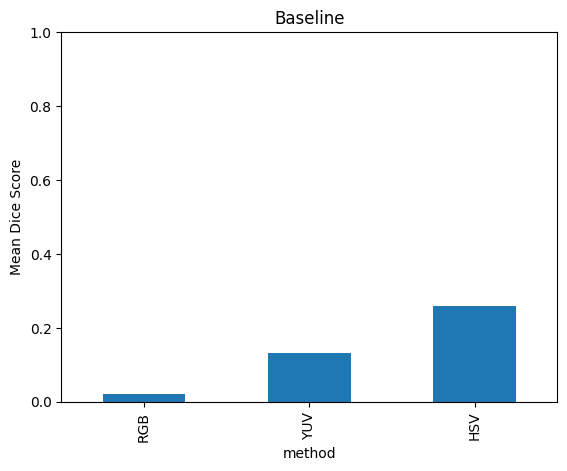

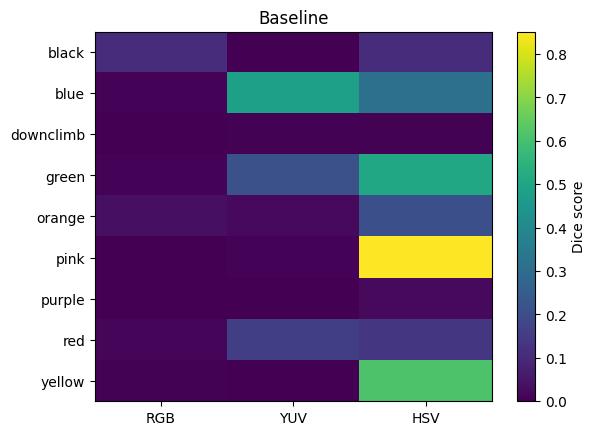

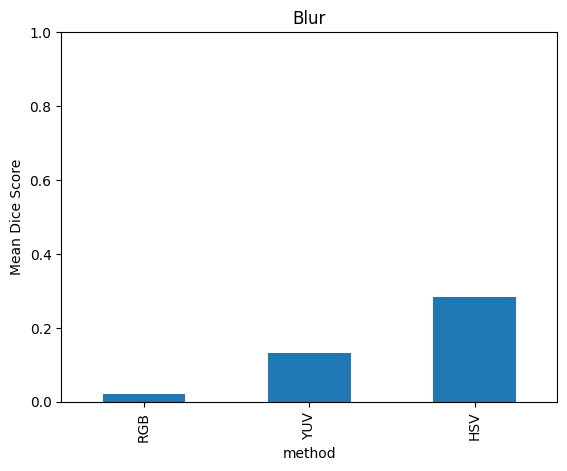

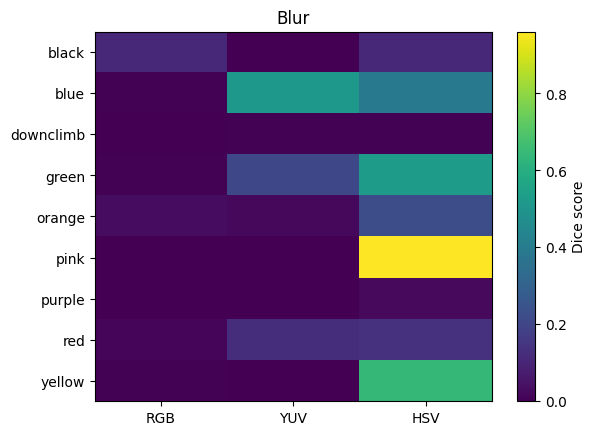

In [13]:
methods = ["RGB", "YUV", "HSV"]

# base
df_base = run_experiment(image_ids, methods, colors_list)
evaluate(df_base, methods, "Baseline")

# blur
df_blur = run_experiment(image_ids, methods, colors_list, pipeline=[blur])
evaluate(df_blur, methods, "Blur")